# KI

## Datenaufbereitung


In [24]:
import pandas as pd
import os

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Trainingsdaten laden

In [25]:
# KI Daten einlesen 

# Pfad zu den Daten
base_path = '../../data/messung_15_12_25'
files = [
    'sand_training_data.csv',
    'grabel_training_data.csv',
    'stone_training_data.csv'
]

# Daten einlesen
data_frames = []
for file in files:
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path, sep=';')                # Einlesen der CSV-Dateien, Trennzeichen ist Semikolon
    data_frames.append(df)

# Zusammenfügen zu einem einzigen DataFrame
full_df = pd.concat(data_frames, ignore_index=True)

# Filtern der Spalten: Wir wollen 'class_name', 'Frequency' und alle 'S_...' Spalten
amplitude_cols = [col for col in full_df.columns if col.startswith('S_')]               # Identifizieren der Spalten, die mit 'S_' beginnen
selected_cols = ['class_name', 'Frequency'] + amplitude_cols                        # Auswahl der gewünschten Spalten
final_df = full_df[selected_cols]

# Anzeigen der ersten Zeilen und der Größe des DataFrames
print(f"Form des DataFrames: {final_df.shape}")
display(final_df.head())

Form des DataFrames: (108, 402)


,class_name,Frequency,S_0,S_1,S_2,S_3,S_4,S_5,S_6,S_7,...,S_390,S_391,S_392,S_393,S_394,S_395,S_396,S_397,S_398,S_399
0,Sand,low,135,198,223,251,257,248,241,238,...,134.0,128.0,119.0,113.0,104.0,94.0,82.0,70.0,57.0,50.0
1,Sand,high,441,356,584,972,981,1221,2550,3768,...,107.0,112.0,128.0,136.0,163.0,195.0,206.0,209.0,211.0,223.0
2,Sand,low,136,200,225,254,260,250,242,239,...,134.0,123.0,112.0,101.0,87.0,72.0,55.0,45.0,43.0,46.0
3,Sand,high,532,425,622,1028,1036,1028,2158,3335,...,260.0,275.0,261.0,221.0,203.0,209.0,208.0,203.0,208.0,218.0
4,Sand,low,138,202,226,254,261,251,243,241,...,162.0,159.0,151.0,142.0,128.0,113.0,101.0,92.0,80.0,72.0


### Ausgabe vo 20 Zeitreihen pro klasse in ein Diagramm

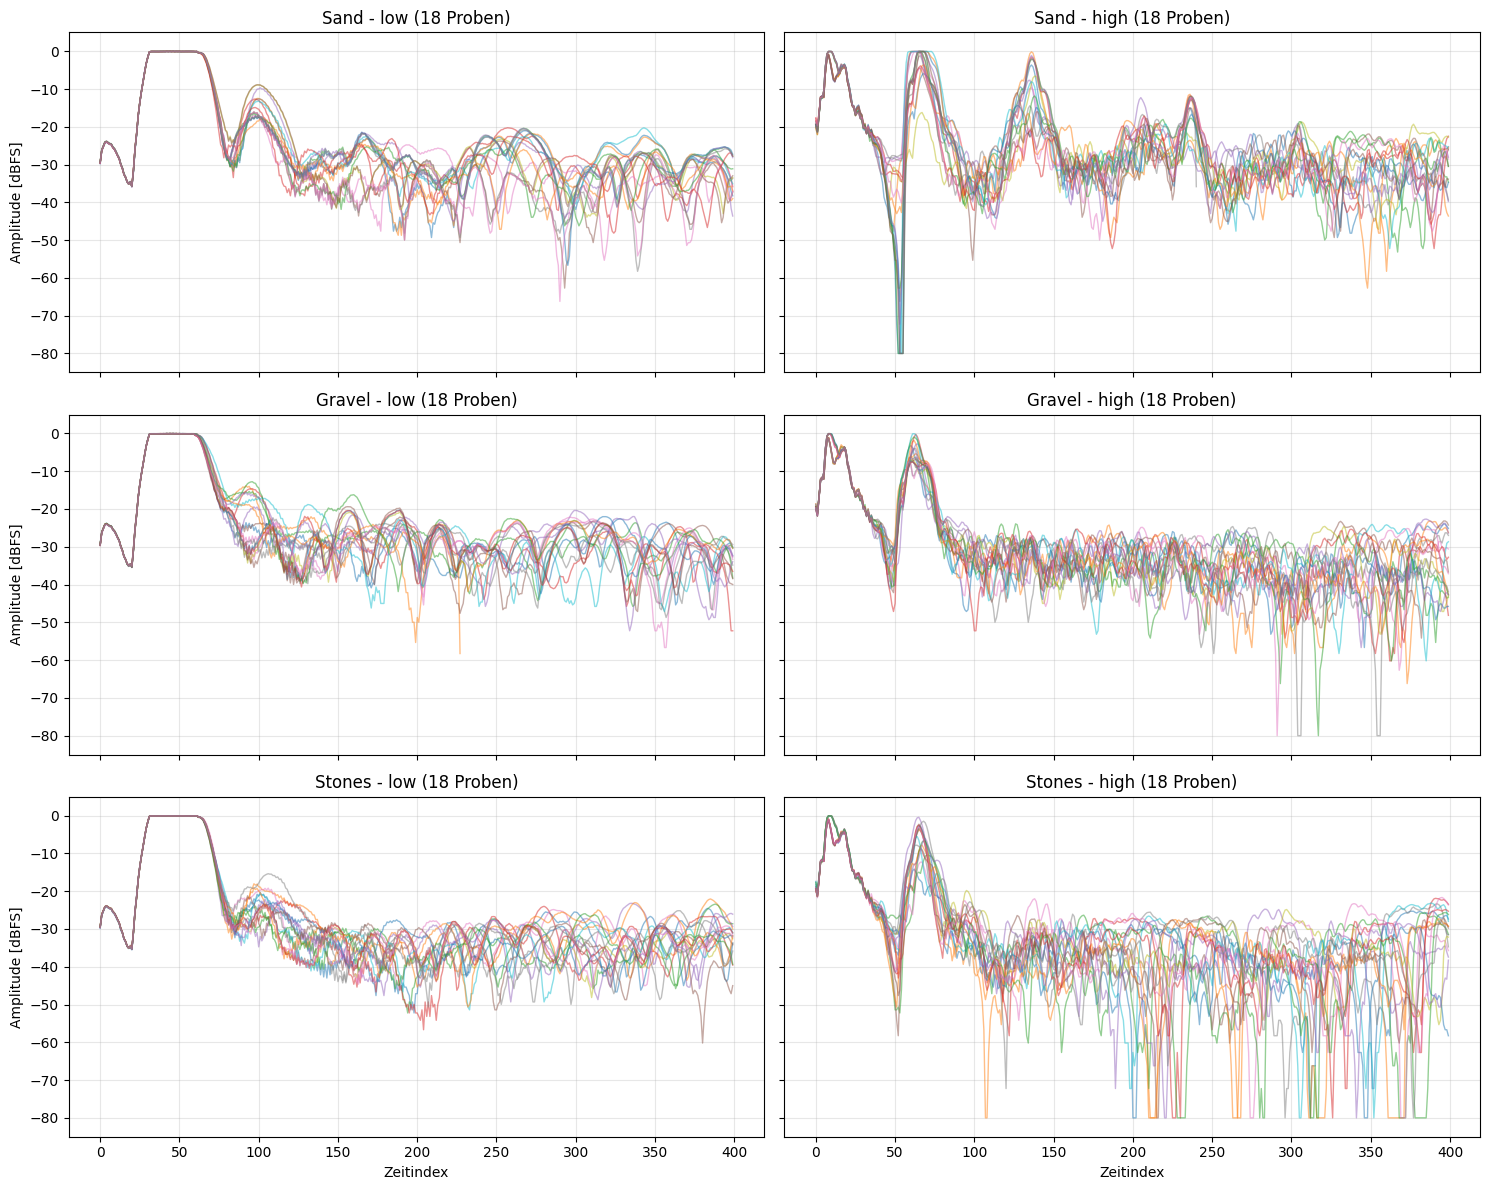

In [26]:
# Eindeutige Klassen finden
classes = ['Sand', 'Gravel', 'Stones']
frequencies = ['low', 'high']  # Definierte Reihenfolge

num_classes = len(classes)
num_freqs = len(frequencies)

# Subplots erstellen: Zeilen = Klassen, Spalten = Frequenzen
# sharey='row' sorgt dafür, dass die Y-Achsen innerhalb einer Klasse vergleichbar sind
fig, axes = plt.subplots(num_classes, num_freqs, figsize=(15, 4*num_classes), sharex=True, sharey='row')

# Wenn es nur eine Klasse gibt, ist axes ein 1D Array, wir machen es 2D für konsistente Indizierung
if num_classes == 1:
    axes = np.array([axes])

for i, class_name in enumerate(classes):
    for j, freq in enumerate(frequencies):
        ax = axes[i, j]
        
        # Daten filtern für spezifische Klasse und Frequenz
        subset = final_df[(final_df['class_name'] == class_name) & (final_df['Frequency'] == freq)]
        
        n_samples = min(20, len(subset))
        
        if n_samples > 0:
            # Zufällige Auswahl
            sampled_data = subset.sample(n_samples, random_state=42)
            
            # --- START ÄNDERUNG ---
            # 1. Rohdaten holen (als Float)
            result = sampled_data.drop(columns=['class_name', 'Frequency']).values.astype(float)
            
            # 2. Direkt in dB umrechnen (Vektiorisiert für alle Zeilen gleichzeitig)
            # Normalisieren (/4095), Logarithmieren (20*log10) und Clippen (min -80dB)
            amplitudes = np.clip(20 * np.log10(np.clip(result / 4095.0, 1e-9, 1.0)), -80, 0)
            
            # Plotten
            for row in amplitudes:
                ax.plot(row, alpha=0.5, linewidth=1)
                
            # Y-Achse fixieren (-85 bis 5 dB)
            ax.set_ylim(-85, 5)
            # --- ENDE ÄNDERUNG ---
            ax.set_title(f'{class_name} - {freq} ({n_samples} Proben)')
        else:
            ax.set_title(f'{class_name} - {freq} (Keine Daten)')
        
        ax.grid(True, alpha=0.3)
        
        # Y-Label nur in der ersten Spalte
        if j == 0:
            ax.set_ylabel('Amplitude [dBFS]')
        
        # X-Label nur in der letzten Zeile
        if i == num_classes - 1:
            ax.set_xlabel('Zeitindex')

plt.tight_layout()
plt.show()

## Algorithmus zur Klassifikation 

### Datenvorbereitung


In [27]:
MAX_DEPTH = 4  # None = Beliebig tief (Genau, aber Gefahr von Overfitting). Setze z.B. auf 5 für einfachere Bäume.

# 1. Datenvorbereitung
df_model = final_df.copy()
df_model['Frequency_Code'] = df_model['Frequency'].map({'low': 0, 'high': 1})

# Features zusammenstellen: Amplituden + Frequenz-Code
amplitude_cols = [c for c in df_model.columns if c.startswith('S_')]
feature_cols = amplitude_cols + ['Frequency_Code']

X = df_model[feature_cols].values
y = df_model['class_name'].values

print(f"Feature Matrix Shape: {X.shape} (Samples x Features)")

# Labels in Zahlen umwandeln
le = LabelEncoder()
y_encoded = le.fit_transform(y)


Feature Matrix Shape: (108, 401) (Samples x Features)


#### Trainieren

In [28]:

# 2. Modell erstellen und evaluieren
clf = RandomForestClassifier(n_estimators=100, max_depth=MAX_DEPTH, random_state=42)

# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y_encoded, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {scores}")
print(f"Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")


Cross-Validation Accuracy Scores: [0.95454545 1.         0.90909091 0.80952381 1.        ]
Cross-Validation Accuracy: 0.9346 (+/- 0.1421)


#### Vorhersagen 

In [29]:

# 3. Detaillierte Auswertung (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Classification Report (Test Set):
              precision    recall  f1-score   support

      Gravel       1.00      1.00      1.00         7
        Sand       1.00      1.00      1.00         7
      Stones       1.00      1.00      1.00         8

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



#### Bewertung

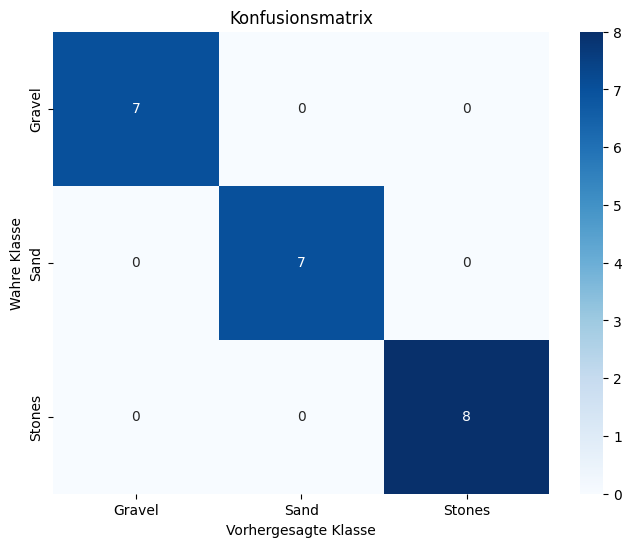

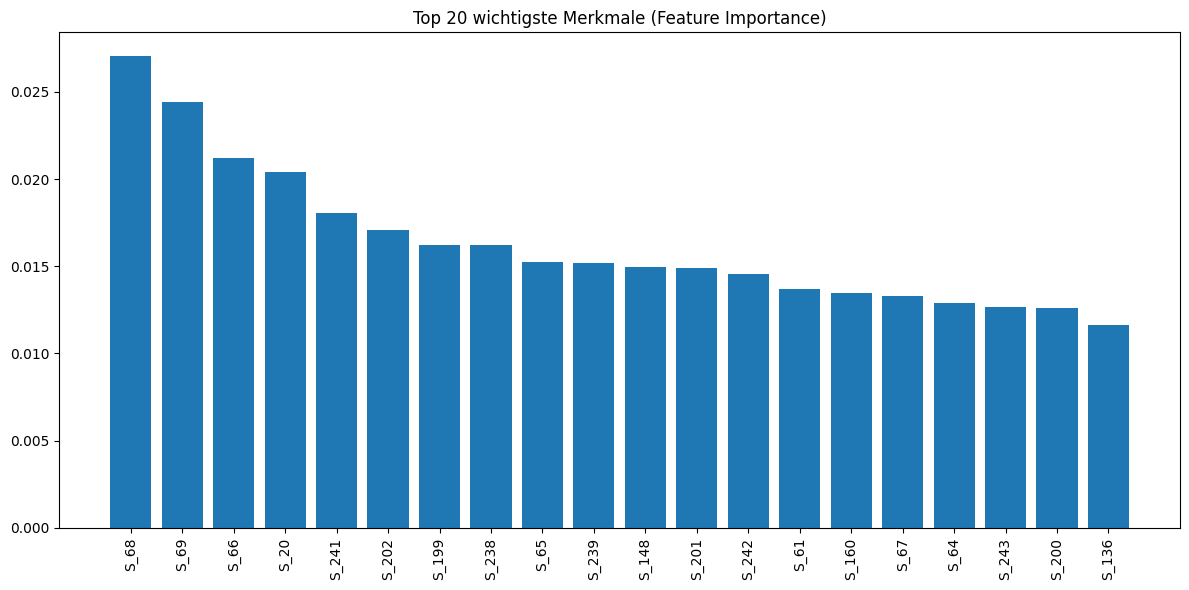


Wichtigkeit der Frequenz-Info: 0.0000


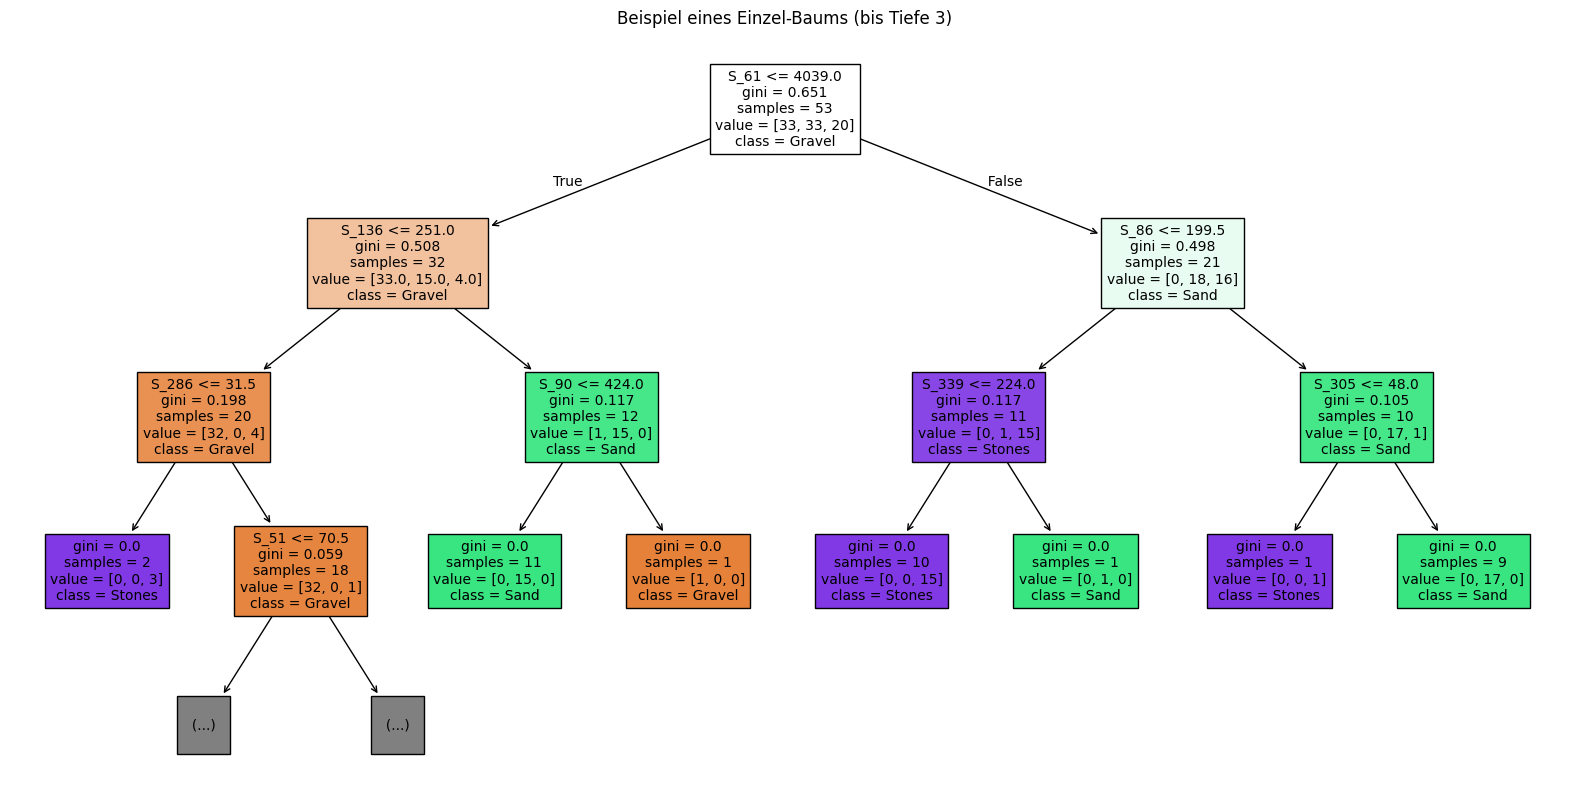

In [30]:
# A) Konfusionsmatrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Wahre Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.title('Konfusionsmatrix')
plt.show()

# B) Feature Importance (Was ist wichtig?)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1][:20] # Top 20

plt.figure(figsize=(12, 6))
plt.title("Top 20 wichtigste Merkmale (Feature Importance)")
plt.bar(range(20), importances[indices], align="center")
plt.xticks(range(20), [feature_cols[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# Wichtigkeit der Frequenz explizit ausgeben
freq_idx = len(feature_cols) - 1
print(f"\nWichtigkeit der Frequenz-Info: {importances[freq_idx]:.4f}")

# C) Entscheidungsbaum visualisieren (Einer aus dem Wald)
plt.figure(figsize=(20, 10))
# Wir begrenzen die Tiefe in der Grafik, damit man noch etwas lesen kann
plot_tree(clf.estimators_[0], feature_names=feature_cols, class_names=le.classes_, filled=True, max_depth=3, fontsize=10)
plt.title("Beispiel eines Einzel-Baums (bis Tiefe 3)")
plt.show()